In [265]:
import numpy as np                  # to do math
from astropy.io import fits         # handline .fits files
import pandas as pd                 # table format
import os                           # universal os
from astroquery.sdss import SDSS    # to query SDSS spectra
import matplotlib.pyplot as plt     # for plotting
from scipy.ndimage import median_filter
from astropy.stats import mad_std

import os

In [266]:
############### Github upload code ##############
# os.system('git status')
# os.system('git add wolf_rayet_spectra_analysis.ipynb')
# os.system('''git commit -m "Created new notebook to inspect wolf-rayet spectra properties"''')
# os.system('git push origin main')

## Querying Confirmed Wolf-Rayet Galaxy Spectra

In [455]:
WR_catalog = pd.DataFrame()

filename = 'table3.dat'  # data file
# accessing file from current directory
file_path = os.path.join('..', filename)

WR_catalog['Running ID'] = list(np.loadtxt(file_path, usecols=1))  
WR_catalog['PMF'] = list(np.loadtxt(file_path, usecols=12, dtype='str'))  
WR_catalog['Z'] = list(np.loadtxt(file_path, usecols=2))  

###### Uncomment once you download table 4, and need to compare EWs ######
filename = 'table5.dat'  # data file
# accessing file from current directory
file_path = os.path.join('..', filename)
WR_catalog['Offical EW'] = list(np.loadtxt(file_path, usecols=10))
WR_catalog['Sigma'] = list(np.loadtxt(file_path, usecols=14))

rest_frame_wavelengths = []
rest_frame_flux_densities = []
rest_frame_flux_density_errs = []
fail = []

WR_num = len(WR_catalog['PMF'])
# WR_num = 3

for i in range(WR_num):
    key = WR_catalog['PMF'][i] 
    plate, mjd, fiber = np.int64((np.array(key.split('-'))))
    z = WR_catalog['Z'][i]


    # try to query spectra from SDSS archive
    try:
        # query
        spec = SDSS.get_spectra(plate=plate,mjd=mjd,fiberID=fiber) #, cache=False)
        
        if spec is not None:
            hdu = spec[0]  # header-data unit (hdu)
            
            # ----------- saving spectral data ------------

            # wavelength
            # wavelength
            log_wav = hdu[1].data['loglam']
            wavelength = 10**log_wav                         # [A]
            rest_wavelength = wavelength / (1+z)             # convert spectrum from observed frame to rest frame using the object's redshift
            section = (rest_wavelength > 4500) & (rest_wavelength < 4850)
            if len(rest_wavelength[section]) < 100:
                print('bad')
                WR_catalog.drop(i, inplace=True) 
                continue 
    
            rest_frame_wavelengths.append(rest_wavelength)   # ... saving these data

            # flux
            flux_density_factor = hdu[1].data['flux']             # 10^-17 * [ergs / s / cm^2 / A]
            flux_density = 10**(-17) * flux_density_factor        # [ergs / s / cm^2 / A]
            rest_flux_density = flux_density * (1+z)              # convert spectrum from observed frame to rest frame using the object's redshift
            rest_frame_flux_densities.append(rest_flux_density)   # ... saving these data
            # ----------------------------------------------
            
            # # flux error
            ivar = hdu[1].data['ivar']
            flux_density_err = np.zeros_like(flux_density)
            good = ivar > 0                                             # avoid dividing by zero
            flux_density_err[good] = 1e-17 / np.sqrt(ivar[good])
            rest_flux_density_err = flux_density_err * (1+z)            # convert spectrum from observed frame to rest frame using the object's redshift
            rest_frame_flux_density_errs.append(rest_flux_density_err)  # ... saving these data

            print(f'successfully saved spectrum for {key}')

        else: 
            print('dropped')
            fail.append(i)
            WR_catalog.drop(i, inplace=True)  # drop any rows (galaxies) that we couldnt successfully queryS
            
            # if unable to find spectra, give exception
    except Exception as e:
        print(f"Failed to retrieve spectrum for {key}: {e}")
        # initial_VMS_eBOSS.drop(i, inplace=True)  # drop any rows (galaxies) that we couldnt successfully query
    
print(f'\nquery complete for {WR_num} galaxies')

# fail_np = np.array(fail)
# for i in fail_np:
#     # initial_VMS_eBOSS.drop(i, inplace=True)  # drop any rows (galaxies) that we couldnt successfully queryS




successfully saved spectrum for 0266-51630-407
successfully saved spectrum for 0267-51608-384
successfully saved spectrum for 0270-51909-265
successfully saved spectrum for 0271-51883-583
successfully saved spectrum for 0272-51941-542
successfully saved spectrum for 0273-51957-464
successfully saved spectrum for 0274-51913-187
successfully saved spectrum for 0275-51910-015
successfully saved spectrum for 0276-51909-197
successfully saved spectrum for 0278-51900-469
successfully saved spectrum for 0280-51612-270
successfully saved spectrum for 0281-51614-230
successfully saved spectrum for 0282-51658-029
dropped


dropped
successfully saved spectrum for 0285-51930-348
successfully saved spectrum for 0289-51990-113
successfully saved spectrum for 0289-51990-378
successfully saved spectrum for 0290-51941-021
successfully saved spectrum for 0293-51994-075
successfully saved spectrum for 0301-51942-081
successfully saved spectrum for 0301-51942-604
successfully saved spectrum for 0305-51613-202
successfully saved spectrum for 0306-51637-599
successfully saved spectrum for 0307-51663-111
successfully saved spectrum for 0308-51662-081
successfully saved spectrum for 0308-51662-326
successfully saved spectrum for 0331-52368-445
successfully saved spectrum for 0332-52367-066
successfully saved spectrum for 0334-51993-065
successfully saved spectrum for 0337-51997-097
successfully saved spectrum for 0337-51997-284
successfully saved spectrum for 0337-51997-425
successfully saved spectrum for 0339-51692-083
successfully saved spectrum for 0342-51691-081
successfully saved spectrum for 0348-51671-279
succe

dropped
successfully saved spectrum for 0372-52173-631
successfully saved spectrum for 0381-51811-370
successfully saved spectrum for 0390-51900-106
successfully saved spectrum for 0390-51900-445
successfully saved spectrum for 0394-51913-075
successfully saved spectrum for 0397-51794-203
successfully saved spectrum for 0398-51789-294
successfully saved spectrum for 0399-51817-322
successfully saved spectrum for 0407-51820-162
successfully saved spectrum for 0409-51871-237
successfully saved spectrum for 0409-51871-548
successfully saved spectrum for 0413-51929-006
successfully saved spectrum for 0413-51929-220
successfully saved spectrum for 0417-51821-513
successfully saved spectrum for 0418-51817-302
successfully saved spectrum for 0419-51879-529
successfully saved spectrum for 0427-51900-291
successfully saved spectrum for 0429-51820-040
successfully saved spectrum for 0439-51877-216


dropped
successfully saved spectrum for 0440-51885-151
successfully saved spectrum for 0441-51868-303
successfully saved spectrum for 0443-51873-514
successfully saved spectrum for 0445-51873-324
successfully saved spectrum for 0445-51873-404
successfully saved spectrum for 0451-51908-595
successfully saved spectrum for 0455-51909-047
successfully saved spectrum for 0455-51909-073
successfully saved spectrum for 0456-51910-077
successfully saved spectrum for 0460-51924-592
successfully saved spectrum for 0473-51929-422
successfully saved spectrum for 0480-51989-578
successfully saved spectrum for 0481-51908-289
successfully saved spectrum for 0485-51909-306
successfully saved spectrum for 0485-51909-550
successfully saved spectrum for 0490-51929-128
successfully saved spectrum for 0490-51929-279
successfully saved spectrum for 0490-51929-502
successfully saved spectrum for 0501-52235-330
successfully saved spectrum for 0501-52235-602
successfully saved spectrum for 0508-52366-357
succe

dropped
dropped
successfully saved spectrum for 0525-52295-626
successfully saved spectrum for 0526-52312-097
successfully saved spectrum for 0527-52342-271
successfully saved spectrum for 0531-52028-048
successfully saved spectrum for 0531-52028-218
successfully saved spectrum for 0532-51993-377
successfully saved spectrum for 0536-52024-575


...

successfully saved spectrum for 2240-53823-220
successfully saved spectrum for 2244-53795-581
successfully saved spectrum for 2264-53682-424
successfully saved spectrum for 2266-53679-279
successfully saved spectrum for 2273-53709-378
successfully saved spectrum for 2275-53709-484
successfully saved spectrum for 2286-53700-071
successfully saved spectrum for 2287-53705-462
successfully saved spectrum for 2288-53699-537


dropped
successfully saved spectrum for 2343-53735-577
successfully saved spectrum for 2345-53757-620
successfully saved spectrum for 2347-53757-133
successfully saved spectrum for 2354-53799-121


dropped
dropped
successfully saved spectrum for 2355-53792-436
successfully saved spectrum for 2355-53792-574
successfully saved spectrum for 2356-53786-184
dropped


successfully saved spectrum for 2358-53797-234
successfully saved spectrum for 2359-53826-205
successfully saved spectrum for 2359-53826-222
successfully saved spectrum for 2361-53762-523
successfully saved spectrum for 2362-53759-003
successfully saved spectrum for 2362-53759-628
successfully saved spectrum for 2363-53763-290
successfully saved spectrum for 2364-53737-618
successfully saved spectrum for 2366-53741-124
successfully saved spectrum for 2367-53763-416
successfully saved spectrum for 2369-53733-355
successfully saved spectrum for 2374-53765-540
successfully saved spectrum for 2376-53770-340
successfully saved spectrum for 2426-53795-015
successfully saved spectrum for 2429-53799-267
successfully saved spectrum for 2430-53815-118
dropped


successfully saved spectrum for 2483-53852-001
successfully saved spectrum for 2491-53855-358
successfully saved spectrum for 2505-53856-295
successfully saved spectrum for 2505-53856-296
successfully saved spectrum for 2511-53882-076
dropped

query complete for 570 galaxies


# # Checking for superficial filtering issues

In [457]:
WR_catalog.reset_index(drop=True, inplace=True)
print(len(WR_catalog))
WR_num = len(WR_catalog)

507


In [391]:
# print(np.shape(rest_frame_flux_densities))
# print(np.shape(rest_frame_wavelengths))

## Calculating WR bump EW

### No bump??

In [458]:
def sectioner(x1, x2, rest_frame_wavelengths, rest_frame_flux_densities):
    '''Separates each section of spectra between two wavelengths

    x1 = shorter wavelength
    x2 = longer wavelength 
    '''
    boolean_array = []
    median_flux_array = []
    median_wavelength_array = []
    # fail = []
    
    for i in range(len(rest_frame_wavelengths)):       #num_filtered):
        section = (rest_frame_wavelengths[i] > x1) & (rest_frame_wavelengths[i] < x2)
        flux_density = rest_frame_flux_densities[i][section]
        waves = rest_frame_wavelengths[i][section]
        if len(waves) < 1:
                print('bad')
                # fail.append(i)
                # WR_catalog.drop(i, inplace=True)
                # continue
                
        median = np.median(flux_density)
        median_idx = np.argmin(np.abs(flux_density - median))
        median_wave = waves[median_idx]
        
        boolean_array.append(section)
        median_flux_array.append(median)
        median_wavelength_array.append(median_wave)

    print('Sectioning Finished')
    return boolean_array, median_flux_array, median_wavelength_array

In [459]:
right_flat, right_median, right_median_wav = sectioner(4560, 4600, rest_frame_wavelengths, rest_frame_flux_densities)
left_flat, left_median, left_median_wav = sectioner(4755, 4795, rest_frame_wavelengths, rest_frame_flux_densities) #should i move this closer to end of wolf_rayet bump?
WolfRayet_bump, blank, blank = sectioner(4600, 4680, rest_frame_wavelengths, rest_frame_flux_densities)
# HeII_bump, bump_median, bump_median_wav = sectioner(4665, 4702, rest_frame_wavelengths, rest_frame_flux_densities)
between, blank, blank = sectioner(4500, 4850, rest_frame_wavelengths, rest_frame_flux_densities)
# outside_bump, outside_median, outside_median_wav = sectioner(4600, 4755, rest_frame_wavelengths, rest_frame_flux_densities)


Sectioning Finished
Sectioning Finished
Sectioning Finished
Sectioning Finished


In [ ]:
# compute just blue bump
wolf_rayet_bump_EWs = []
wolf_rayet_bump_EW_SNR = []

# # #~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting Spectra to determine threshold of Wolf-Rayet EW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# kay = [0]
# k = np.array(kay)
k = np.arange(0, WR_num, 1)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
for i in k:    
    #~~~~~~~ Complicated Finding Median Stuff ~~~~~~~~~~~~~~~~~
    max_flux_median = np.max([right_median[i], left_median[i]])
    min_flux_median = np.min([right_median[i], left_median[i]])
    
    if max_flux_median == right_median[i]:
        max_wave_med = right_median_wav[i]
        min_wave_med = left_median_wav[i]
    elif max_flux_median == left_median[i]: ##### learned elif = else if ######
        max_wave_med = left_median_wav[i]
        min_wave_med = right_median_wav[i]
    else: 
        print('failed result:')
        
    ########## New Method of finding base equation ###########
    y_points = np.array([max_flux_median, min_flux_median])
    x_points = np.array([max_wave_med, min_wave_med])
    
    coefficients = np.polyfit(x_points, y_points, 1)
    linear_func = np.poly1d(coefficients)

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculating EW of Wolf Rayet Blue Bump ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    x2 = rest_frame_wavelengths[i]
    y = rest_frame_flux_densities[i]

    ### Measuring difference between bump flux and baseline equation flux 
    bump_wav = rest_frame_wavelengths[i][WolfRayet_bump[i]]
    bump_flux = rest_frame_flux_densities[i][WolfRayet_bump[i]]
    baseline_flux = linear_func(x2)[WolfRayet_bump[i]]

    delta_bump_flux = bump_flux - baseline_flux
    norm_delta_flux = delta_bump_flux / baseline_flux
    
    ##### Calculating Equivalent Width of WolfRayet Bump
    EW = np.trapezoid(norm_delta_flux, bump_wav)   # integrate   
    wolf_rayet_bump_EWs.append(EW)

    # ###### calcualte noise (sigma) ############
    normalized_flux_err = rest_frame_flux_density_errs[i][WolfRayet_bump[i]] / baseline_flux
    integration_weights = np.gradient(bump_wav)
    squares = (normalized_flux_err * integration_weights)**2
    sum = np.sum(squares)
    sigma = np.sqrt(sum)
    SNR = EW /sigma #### Should I change this to SNR sum because we're only taking the SNR of the bump
    wolf_rayet_bump_EW_SNR.append(SNR) 
    # # ----------------------

# print('success')
print(np.shape(wolf_rayet_bump_EWs))
# print(np.shape(wolf_rayet_bump_EW_SNR)) ### Makes to signal to noise ratio for whole spectra
# print(wolf_rayet_bump_EW_SNR[0])

(507,)


In [461]:
# print(wolf_rayet_bump_EWs)
print(np.min(wolf_rayet_bump_EWs))

OG_method_EW = wolf_rayet_bump_EWs

-10.589876174581413


487
(507,)


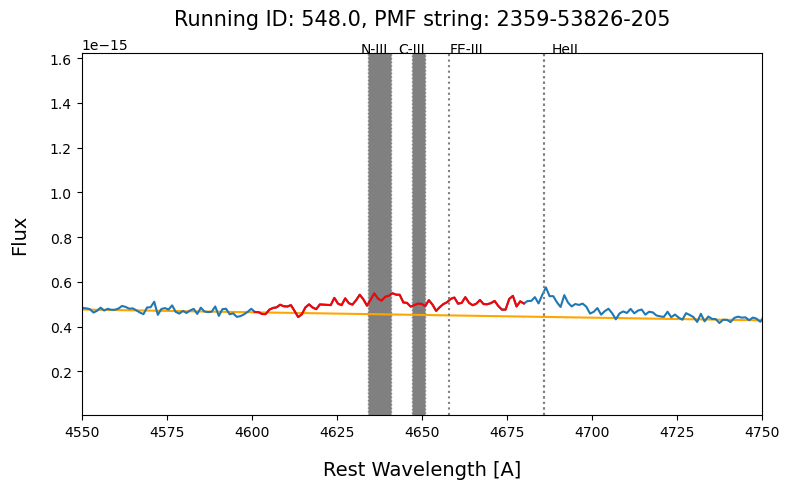

success


In [515]:
# # #~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting Spectra to determine threshold of Wolf-Rayet EW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~

kay = [487]
k = np.array(kay)
# k = np.arange(0, 5, 1)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
for i in k:    
    print(i)
    #~~~~~~~ Complicated Finding Median Stuff ~~~~~~~~~~~~~~~~~
    print(np.shape(right_median))
    max_flux_median = np.max([right_median[i], left_median[i]])
    min_flux_median = np.min([right_median[i], left_median[i]])
    
    if max_flux_median == right_median[i]:
        max_wave_med = right_median_wav[i]
        min_wave_med = left_median_wav[i]
    elif max_flux_median == left_median[i]: ##### learned elif = else if ######
        max_wave_med = left_median_wav[i]
        min_wave_med = right_median_wav[i]
    else: 
        print('failed result:')
        
    ########## New Method of finding base equation ###########
    y_points = np.array([max_flux_median, min_flux_median])
    x_points = np.array([max_wave_med, min_wave_med])
    
    coefficients = np.polyfit(x_points, y_points, 1)
    linear_func = np.poly1d(coefficients)

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculating equivalent wdith of HE II bump ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    x = rest_frame_wavelengths[i]
    y = rest_frame_flux_densities[i]

    ############ Creating axes #################
    highlighted = right_flat[i] | left_flat[i] # "Flat" continuum portions
    
    yblue = rest_frame_flux_densities[i].copy()
    yblue[~highlighted] = np.nan
    
    # ybump = rest_frame_flux_densities[i].copy()
    # ybump[~HeII_bump[i]] = np.nan

    out_bump = rest_frame_flux_densities[i].copy()
    # WolfRayet_bump = outside_bump[i] & (~HeII_bump[i])
    out_bump[~WolfRayet_bump[i]] = np.nan
 
    yspectra = rest_frame_flux_densities[i].copy()
    yspectra[~between[i]] = np.nan

    # baseline = equation.copy()
    baseline = linear_func(x).copy()
    baseline[~between[i]] = np.nan

    plt.figure(figsize=(8,5))
    plt.title(f'Running ID: {WR_catalog['Running ID'][i]}, PMF string: {WR_catalog['PMF'][i]}', fontsize=15, pad=20)

    ############### Plotting ###################
    # plt.plot(x, yspectra, color='black')
    # plt.plot(x, yblue, color='blue')
    # # plt.plot(x, ybump, color='red')
    plt.plot(x, baseline, color='orange')
    # plt.plot(x, out_bump, color ='darkgray')
    # plt.scatter(x_points, y_points, color='green')
    # plt.plot(x, rest_frame_flux_density_errs_2[i])

    (rest_frame_flux_densities[i])
    lower_y_lim = median_flux * 0.008
    upper_y_lim = median_flux * 5

    plt.plot(rest_frame_wavelengths[i], rest_frame_flux_densities[i])
    plt.plot(rest_frame_wavelengths[i], out_bump, color='red')
    plt.xlim(4550, 4750)

    plt.axvline(4686, color='grey',linestyle='dotted', label='HeII')
    plt.axvline(4861, color='grey',linestyle='dotted', label='H-beta')
    plt.axvline(4686, color='grey',linestyle='dotted', label='HeII')
    plt.text(4686+2, upper_y_lim, 'HeII')
    # plt.axvline(4861, color='grey',linestyle='dotted', label='H-beta')
    # plt.text(4861, upper_y_lim, 'H-beta')
    plt.axvspan(4634, 4641, color='grey',linestyle='dotted', label='N-III')
    plt.text(4632, upper_y_lim, 'N-III')
    plt.axvline(4658, color='grey',linestyle='dotted', label='FE-III')
    plt.text(4658, upper_y_lim, 'FE-III')
    plt.axvspan(4647, 4651, color='grey',linestyle='dotted', label='C-III')
    plt.text(4643, upper_y_lim, 'C-III')

    #yscale = log
    # # plt.yscale('log')
    median_flux = np.median(rest_frame_flux_densities[i])
    lower_y_lim = median_flux * 0.008
    upper_y_lim = median_flux * 5
    plt.ylim(lower_y_lim, upper_y_lim)

    plt.xlabel('Rest Wavelength [A]', fontsize=14, labelpad=15)
    plt.ylabel('Flux', fontsize=14, labelpad=15)

    plt.tight_layout() 
    plt.show()


print('success')

In [398]:
# compute just blue bump
MS_bump_EW = []
# wolf_rayet_bump_EW_SNR = []

# # #~~~~~~~~~~~~~~~~~~~~~~~~~ Plotting Spectra to determine threshold of Wolf-Rayet EW ~~~~~~~~~~~~~~~~~~~~~~~~~~~~


# kay = [0]
# k = np.array(kay)
k = np.arange(0, WR_num, 1)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
for i in k:    
    #~~~~~~~ Calculating Flat Continuum Using Median Smoothing ~~~~~~~~~~~~~~~~~
    median_smooth_flux = median_filter(rest_frame_flux_densities[i], size=900, mode='reflect')

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Calculating EW of Wolf-Rayet Blue Bump ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    x2 = rest_frame_wavelengths[i]
    y = rest_frame_flux_densities[i]

    ### Measuring difference between bump flux and baseline equation flux 
    bump_wav = rest_frame_wavelengths[i][WolfRayet_bump[i]]
    bump_flux = rest_frame_flux_densities[i][WolfRayet_bump[i]]

    baseline_flux = median_smooth_flux[WolfRayet_bump[i]]
    delta_bump_flux = bump_flux - baseline_flux
    norm_delta_flux = delta_bump_flux / baseline_flux
    
    ##### Calculating Equivalent Width of WolfRayet Bump
    EW = np.trapezoid(norm_delta_flux, bump_wav)      
    MS_bump_EW.append(EW)


# print('success')
print(np.shape(MS_bump_EW))
# print(MS_bump_EW)
# print(np.shape(wolf_rayet_bump_EW_SNR)) ### Makes to signal to noise ratio for whole spectra
# print(wolf_rayet_bump_EW_SNR[0])

(507,)


## Comparing Methods to Official Measurement

In [ ]:

OG_percentdiff = []
MS_percentdiff = []

k = np.arange(0,506, 1)
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


for i in k:
    # print(i)
    EW = WR_catalog['Offical EW'][i]

    OG_ratio = np.abs(EW-OG_method_EW[i])/EW
    OG_percent = OG_ratio * 100
    OG_percentdiff.append(OG_percent)

    MS_ratio = np.abs(EW-MS_bump_EW[i])/EW
    MS_percent = MS_ratio * 100
    MS_percentdiff.append(MS_percent)

OG_ave_percentdiff = np.mean(OG_percentdiff)
print(OG_ave_percentdiff)
MS_ave_percentdiff = np.mean(MS_percentdiff)
print(MS_ave_percentdiff)

39.35141323542758
56.7603981359412


Paper EW: 10.81
Paper Sigma: 17.02

My EW: 8.35
My SNR: 21.41


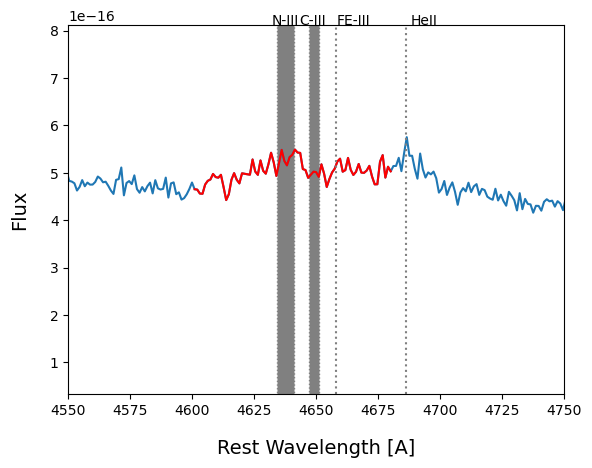

In [507]:
i = 487

print(f'Paper EW: {WR_catalog['Offical EW'][i]}')
print(f'Paper Sigma: {WR_catalog['Sigma'][i]}')
print()
print(f'My EW: {OG_method_EW[i]:.2f}')
print(f'My SNR: {wolf_rayet_bump_EW_SNR[i]:.2f}')

out_bump = rest_frame_flux_densities[i].copy()
out_bump[~WolfRayet_bump[i]] = np.nan

plt.plot(rest_frame_wavelengths[i], rest_frame_flux_densities[i])
plt.plot(rest_frame_wavelengths[i], out_bump, color='red')
plt.xlim(4550, 4750)

median_flux = np.median(rest_frame_flux_densities[i])
lower_y_lim = median_flux * 0.1
upper_y_lim = median_flux * 2.5

plt.axvline(4686, color='grey',linestyle='dotted', label='HeII')
plt.text(4686+2, upper_y_lim, 'HeII')
# plt.axvline(4861, color='grey',linestyle='dotted', label='H-beta')
# plt.text(4861, upper_y_lim, 'H-beta')
plt.axvspan(4634, 4641, color='grey',linestyle='dotted', label='N-III')
plt.text(4632, upper_y_lim, 'N-III')
plt.axvline(4658, color='grey',linestyle='dotted', label='FE-III')
plt.text(4658, upper_y_lim, 'FE-III')
plt.axvspan(4647, 4651, color='grey',linestyle='dotted', label='C-III')
plt.text(4643, upper_y_lim, 'C-III')

plt.xlabel('Rest Wavelength [A]', fontsize=14, labelpad=15)
plt.ylabel('Flux', fontsize=14, labelpad=15)

plt.ylim(lower_y_lim, upper_y_lim)

plt.show()

In [491]:
# print(np.min(WR_catalog['Sigma']))

WR_catalog[(WR_catalog['Offical EW'] > 5)] #& (WR_catalog['Offical EW'] < 1.8)]

,Running ID,PMF,Z,Offical EW,Sigma
2,2.0,0270-51909-265,0.04478,5.79,3.65
16,18.0,0290-51941-021,0.08101,5.17,8.87
18,20.0,0301-51942-081,0.02436,6.03,4.55
24,26.0,0308-51662-326,0.00628,8.36,9.39
25,27.0,0331-52368-445,0.03538,10.13,14.62
...,...,...,...,...,...
485,545.0,2356-53786-184,0.03448,8.64,9.18
487,548.0,2359-53826-205,0.00452,10.81,17.02
489,550.0,2361-53762-523,0.04480,7.83,9.22
498,559.0,2376-53770-340,0.06518,5.28,12.10


In [415]:
WR_catalog 

,Running ID,PMF,Z,Offical EW,Sigma
0,0.0,0266-51630-407,0.05160,2.64,10.15
1,1.0,0267-51608-384,0.00633,2.29,10.42
2,2.0,0270-51909-265,0.04478,5.79,3.65
3,3.0,0271-51883-583,0.02149,2.97,8.33
4,4.0,0272-51941-542,0.02148,1.69,7.84
...,...,...,...,...,...
502,564.0,2483-53852-001,0.03673,2.22,6.71
503,565.0,2491-53855-358,0.03210,1.78,7.19
504,566.0,2505-53856-295,0.02323,3.77,9.67
505,567.0,2505-53856-296,0.03335,4.07,12.13
